In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data_path = '/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/arcmg/data/pendulum_lqr/pendulum_roa.txt'
data = np.loadtxt(data_path)[::10, 1:]

data[:, 0] /= np.pi
data[:, 1] /= (2*np.pi)
print(data.shape)

(79066, 3)


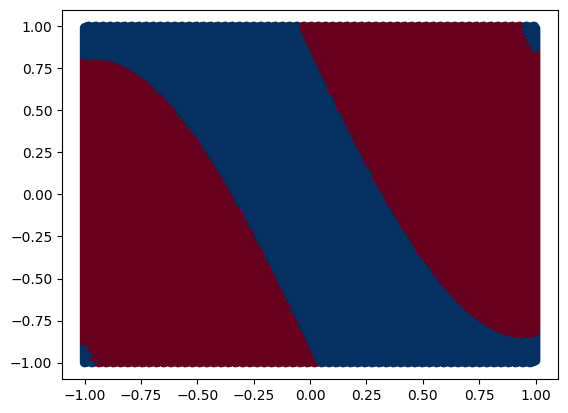

In [4]:
# given data[:, 0] is theta, data[:, 1] is dtheta, data[:, 2] needs to be plotted. 0 is red and 1 is blue
plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='RdBu')
plt.show()

In [51]:
from experiments.systems.pendulum import Pendulum
system = Pendulum()
attractors = system.attractors()
attractors

[array([0, 0]), array([2.1, 0. ]), array([-2.1,  0. ])]

In [52]:
from representation_learning.utils.config import ConfigManager
from representation_learning.classifier.trainers.classifier_trainer import ClassifierTrainer
config_file = "representation_learning/configs/classifier_config.yaml"
config = ConfigManager.load_config(config_file)
trainer = ClassifierTrainer(config)

representation_learning/configs/classifier_config.yaml
outputs/distillation/config.yaml
/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/arcmg/data/pendulum_lqr/reachability_dataset_5k_diff_balance_small.npz


/home/dhruv/2024/projects/arcmg/representation_learning/classifier/trainers/classifier_trainer.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [53]:
trainer.load_checkpoint("outputs/5k_diff_balance_small/best_model.pth")


2024-11-27 09:55:43,204 - ClassifierTrainer - INFO - Loading checkpoint from outputs/5k_diff_balance_small/best_model.pth


In [54]:
model = trainer.model
model.eval()

ReachabilityClassifier(
  (network): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [55]:
for attractor in attractors:
    for i in range(len(data)):
        source = data[i, :2]
        target = attractor
        
        # with torch.no_grad():
        #     output = model(source, target)
        # print(output)
    

In [56]:
def create_batch_around_attractor(attractor, radius, num_samples):
    samples = np.random.normal(0, 0.1, (num_samples, 2))
    samples = samples / np.linalg.norm(samples, axis=1).reshape(-1, 1)
    samples = samples * radius
    samples = samples + attractor
    return samples

In [57]:
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm
class PendulumDataset(Dataset):
    def __init__(self, data, distillation_model):
        self.data = data
        # self.data[:, 0] /= np.pi
        # self.data[:, 1] /= (2*np.pi)
        self.distillation_model = distillation_model
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        source = torch.tensor(self.data[idx, :2], dtype=torch.float32)
        with torch.no_grad():
            return source, self.distillation_model(source)
        
distillation_model = trainer.distillation_model
dataset = PendulumDataset(data, distillation_model)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, pin_memory=True)

attractor_classifications = {
    i: [] for i in range(len(attractors))
}
for i in range(len(attractors)):
    clf_data = []
    attractor = attractors[i]
    
    # sample 32 points around the attractor at a radius of 0.05
    points = create_batch_around_attractor(attractor, 0.05, 64)
    points[-1, :] = attractor
    points[:, 0] /= np.pi
    points[:, 1] /= (2*np.pi)
    target_repr_1 = distillation_model(torch.tensor(points, dtype=torch.float32))
    
    pbar = tqdm(dataloader, desc=f"Processing attractor {i}")
    for (raw_source, source_repr) in pbar:
        source_repr = source_repr.repeat(64, 1)
        target_repr = target_repr_1.clone()
        inp = torch.cat((source_repr, target_repr), dim=1).to(trainer.device)
        with torch.no_grad():
            output = np.max(torch.sigmoid(model(inp)).cpu().numpy()).reshape(-1, 1)
        raw_source = raw_source.numpy()
        clf_data.append(np.concatenate((raw_source, output), axis=1))
    attractor_classifications[i] = np.concatenate(clf_data, axis=0)
    #     raw_source = raw_source.numpy()
    #     clf_data.append(np.concatenate((raw_source, output), axis=1))
    # attractor_classifications[i] = np.concatenate(clf_data, axis=0)
    # print(attractor_classifications[i].shape)
    # break


Processing attractor 0:  99%|█████████▉| 78099/79066 [00:53<00:00, 1446.83it/s]


KeyboardInterrupt: 

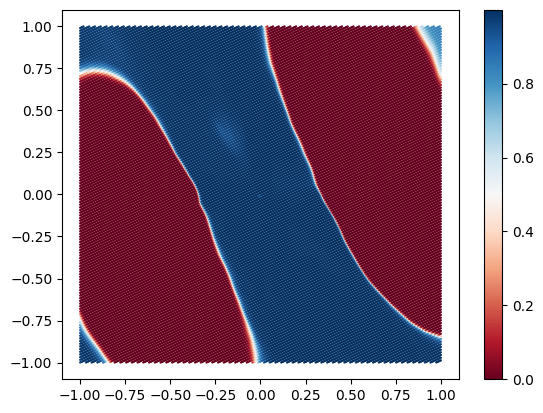

In [11]:
# attractor_classifications[0].shape
# plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='Greys', alpha=0.5, s=0.5)
plt.scatter(attractor_classifications[0][:, 0], attractor_classifications[0][:, 1], c=attractor_classifications[0][:, 2], cmap='RdBu', s=0.3)
plt.colorbar()

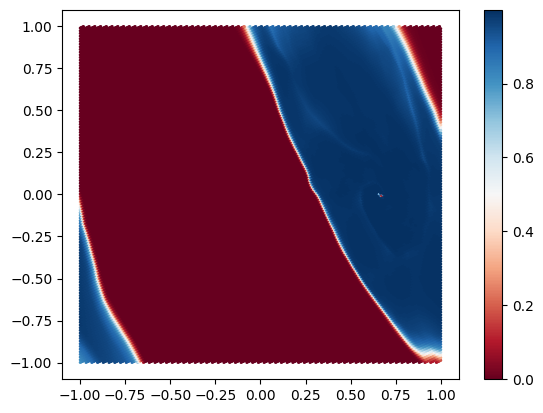

In [14]:
plt.scatter(attractor_classifications[1][:, 0], attractor_classifications[1][:, 1], c=attractor_classifications[1][:, 2], cmap='RdBu', s=1)
plt.colorbar()
plt.show()

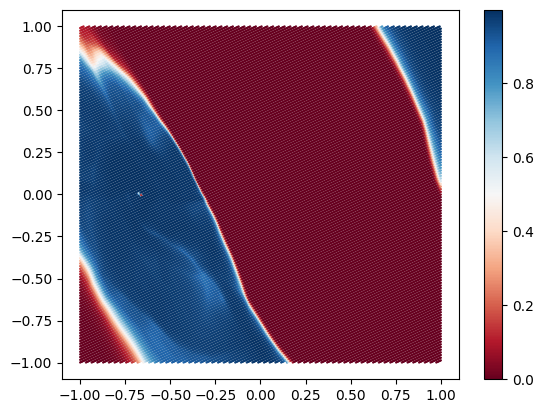

In [15]:
plt.scatter(attractor_classifications[2][:, 0], attractor_classifications[2][:, 1], c=attractor_classifications[2][:, 2], cmap='RdBu', s=0.3)
plt.colorbar()
plt.show()

In [17]:
total_prob = attractor_classifications[0][:, 2] + attractor_classifications[1][:, 2] + attractor_classifications[2][:, 2]
norm_probs = {
    i: attractor_classifications[i][:, 2] / total_prob for i in range(len(attractor_classifications))
}
norm_probs[1] += norm_probs[2]

Text(0.5, 1.0, 'Attractor 0')

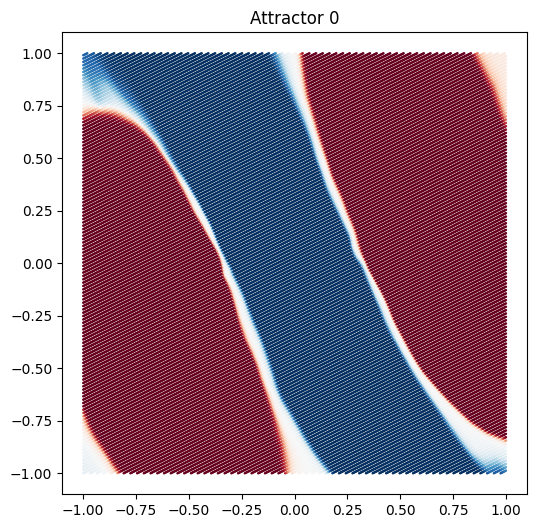

In [19]:
# make a 3d plot of the attractor classifications with normalized probabilities
# 3d plot of attractor_classifications[0]
# make a 3d plot interactive
# import plotly.graph_objects as go
# fig = go.Figure()
# fig.add_trace(go.Scatter3d(x=attractor_classifications[0][:, 0], y=attractor_classifications[0][:, 1], z=norm_probs[0], mode='markers', marker=dict(color=norm_probs[0], size=0.3, colorscale='RdBu')))
# fig.add_trace(go.Scatter3d(x=attractor_classifications[1][:, 0], y=attractor_classifications[1][:, 1], z=norm_probs[1], mode='markers', marker=dict(color=norm_probs[1], size=0.3, colorscale='RdBu')))
# fig.add_trace(go.Scatter3d(x=attractor_classifications[2][:, 0], y=attractor_classifications[2][:, 1], z=norm_probs[2], mode='markers', marker=dict(color=norm_probs[2], size=0.3, colorscale='RdBu')))
# fig.show()



fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)  
ax.scatter(attractor_classifications[0][:, 0], attractor_classifications[0][:, 1], c=norm_probs[0], cmap='RdBu', s=0.5)
# ax.scatter(attractor_classifications[0][:, 0], attractor_classifications[0][:, 1], c=data[:, 2], cmap='RdBu', s=0.3)
ax.set_title('Attractor 0')
# ax.colorbar()
# ax = fig.add_subplot(1, 2, 2)  
# ax.scatter(attractor_classifications[1][:, 0], attractor_classifications[1][:, 1],  c=norm_probs[1], cmap='RdBu', s=0.3)
# ax.set_title('Attractor 1')
# ax = fig.add_subplot(1, 3, 3)  
# ax.scatter(attractor_classifications[2][:, 0], attractor_classifications[2][:, 1], c=norm_probs[2], cmap='RdBu', s=0.3)
# ax.set_title('Attractor 2')
# # make it interactive
# plt.show()
# ax[1].scatter(attractor_classifications[1][:, 0], attractor_classifications[1][:, 1], c=norm_probs[1], cmap='RdBu', s=0.3)
# ax[2].scatter(attractor_classifications[2][:, 0], attractor_classifications[2][:, 1], c=norm_probs[2], cmap='RdBu', s=0.3)
# plt.show()

# put them all together
# plt.scatter(attractor_classifications[0][:, 0], attractor_classifications[0][:, 1], c=norm_probs[0], cmap='RdBu', s=0.3)

# plt.show()


In [35]:
idx = np.random.randint(len(attractor_classifications[0]))
attractor_classifications[0][idx, 2], attractor_classifications[1][idx, 2], attractor_classifications[2][idx, 2], norm_probs[0][idx], norm_probs[1][idx]

(np.float32(0.9970163),
 np.float32(0.0),
 np.float32(8.881592e-34),
 np.float32(1.0),
 np.float32(8.908171e-34))

In [7]:
from representation_learning.utils.config import ConfigManager
from representation_learning.classifier.trainers.probability_trainer import ProbabilityTrainer
from representation_learning.classifier.data.dataset import ProbabilityDataset
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
from experiments.systems.pendulum import Pendulum



class PendulumProbabilityDataset(ProbabilityDataset):
    def __init__(self, data, labels, distillation_model, use_representations=True, classifier_model=None):
        self.data = data
        self.labels = labels
        self.distillation_model = distillation_model
        self.use_representations = use_representations
        self.classifier_model = classifier_model
        
        system = Pendulum()
        self.attractors = system.attractors()

config_file = "representation_learning/configs/probability_config.yaml"
config = ConfigManager.load_config(config_file)
probability_trainer = ProbabilityTrainer(config)
probability_trainer.load_checkpoint("outputs/probability_classifier/best_model.pth")
model = probability_trainer.model
model.eval()

# labels = np.array([[attractor_classifications[i][j, 2].item() for i in range(len(attractor_classifications))] for j in range(len(data))])
labels = np.zeros((len(data), 3))
dataset = PendulumProbabilityDataset(data, labels, probability_trainer.distillation_model, use_representations=True, classifier_model=probability_trainer.classifier_model)
dataloader = DataLoader(dataset, batch_size=2048, shuffle=False, pin_memory=True)

/home/dhruv/2024/projects/arcmg/representation_learning/classifier/trainers/probability_trainer.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(

representation_learning/configs/probability_config.yaml
outputs/distillation/config.yaml
outputs/5k_diff_balance_small/config.yaml
{'dropout': 0.0, 'hidden_dims': [512, 512, 512], 'input_dim': 128}


In [8]:
raw_data = []
classifier_out = []
prob_out = []
pbar = tqdm(dataloader, desc="Processing dataset")
for i, (raw_inp, inp, label) in enumerate(pbar):
    inp = inp.to(probability_trainer.device)
    with torch.no_grad():
        output = model(inp)

    raw_data.append(raw_inp.numpy())
    classifier_out.append(inp[:, -3:].cpu().numpy())
    prob_out.append(torch.softmax(output, dim=1).squeeze(0).cpu().numpy())
    # prob_data.append((inp.squeeze(0).cpu().numpy(), torch.softmax(output, dim=1).squeeze(0).cpu().numpy()))
# prob_data = np.concatenate(prob_data, axis=0)

Processing dataset: 100%|██████████| 39/39 [03:06<00:00,  4.79s/it]


In [9]:
new_raw_data = np.concatenate(raw_data, axis=0)
new_classifier_out = np.concatenate(classifier_out, axis=0)
new_prob_out = np.concatenate(prob_out, axis=0)

# save the data
np.savez('outputs/probability_classifier/prob_data.npz', raw_data=new_raw_data, classifier_out=new_classifier_out, prob_out=new_prob_out)

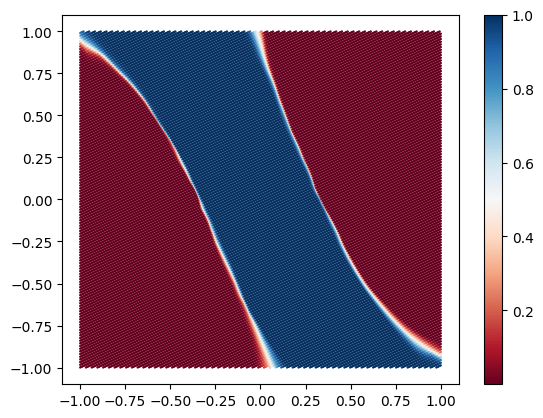

In [11]:
plt.scatter(new_raw_data[:, 0], new_raw_data[:, 1], c=new_prob_out[:, 0], cmap='RdBu', s=0.3)
plt.colorbar()
plt.show()

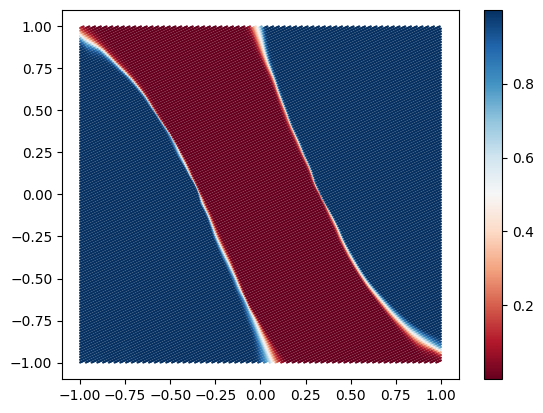

In [12]:
plt.scatter(new_raw_data[:, 0], new_raw_data[:, 1], c=new_prob_out[:, 1] + new_prob_out[:, 2], cmap='RdBu', s=0.3)
plt.colorbar()
plt.show()

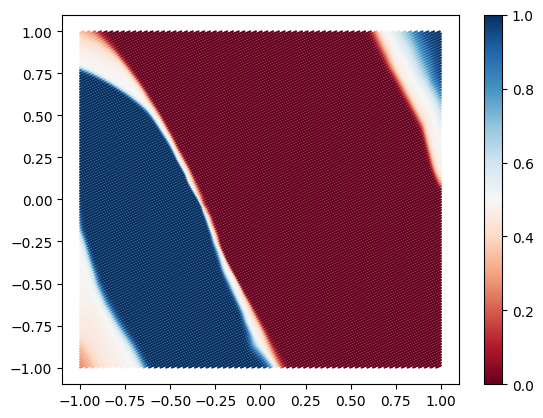

In [28]:
plt.scatter(attractor_classifications[2][:, 0], attractor_classifications[2][:, 1], c=norm_probs[2], cmap='RdBu', s=0.3)
plt.colorbar()
plt.show()

In [44]:
att_clf = attractor_classifications[1].copy()
for i in range(len(attractor_classifications[1])):
    att_clf[i, 2] = max(att_clf[i, 2], attractor_classifications[2][i, 2])

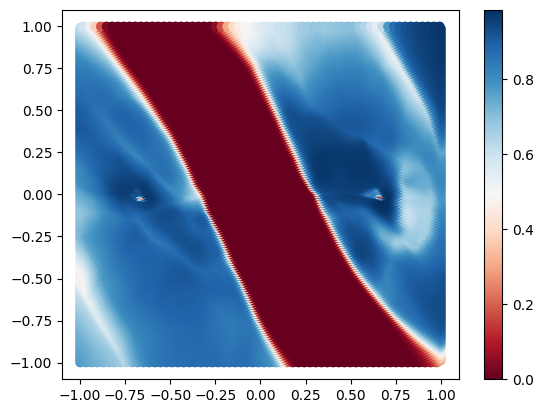

In [46]:
plt.scatter(att_clf[:, 0], att_clf[:, 1], c=att_clf[:, 2], cmap='RdBu')
plt.colorbar()
plt.show()

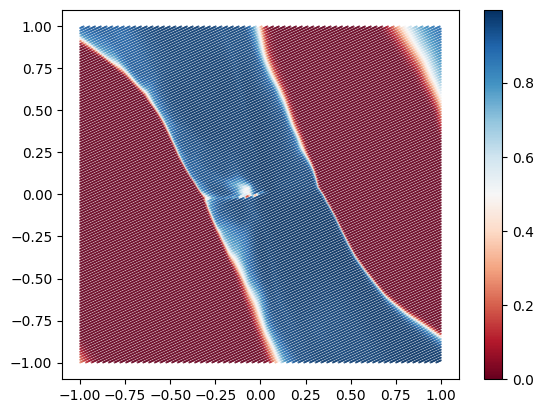

In [48]:
# attractor_classifications[0].shape
plt.scatter(attractor_classifications[0][:, 0], attractor_classifications[0][:, 1], c=attractor_classifications[0][:, 2], cmap='RdBu', s=0.1)
plt.colorbar()
# plt.scatter(data[data[:, 2] == 0][:, 0], data[data[:, 2] == 0][:, 1], c=data[data[:, 2] == 0][:, 2], cmap='RdBu', alpha=0.2)

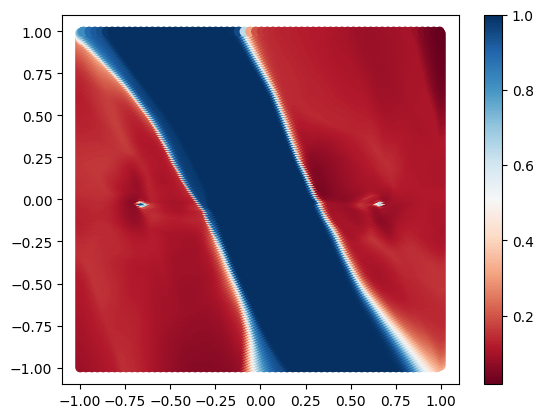

In [25]:
final_clf = att_clf.copy()
for i in range(len(attractor_classifications[0])):
    final_clf[i, 2] = max(1-final_clf[i, 2], attractor_classifications[0][i, 2])
plt.scatter(final_clf[:, 0], final_clf[:, 1], c=final_clf[:, 2], cmap='RdBu')
plt.colorbar()
plt.show()



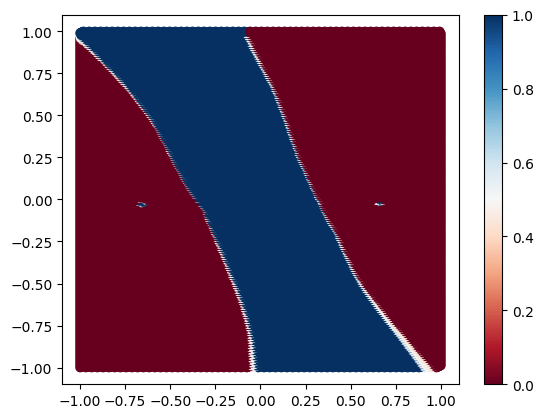

In [26]:
new_final_clf = final_clf.copy()
new_final_clf[final_clf[:, 2] < 0.4, 2] = 0
new_final_clf[final_clf[:, 2] > 0.6, 2] = 1

plt.scatter(new_final_clf[:, 0], new_final_clf[:, 1], c=new_final_clf[:, 2], cmap='RdBu')
plt.colorbar()
plt.show()



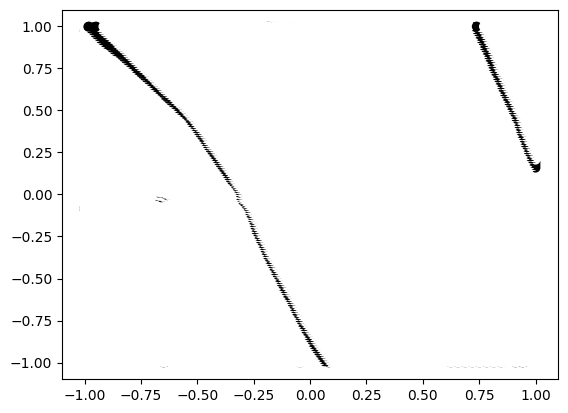

In [27]:
for i in range(len(attractor_classifications)): 
    d1 = attractor_classifications[i].copy()
    # d2 = attractor_classifications[i].copy()
    d1[d1[:, 2] < 0.4, 2] = 0
    d1[d1[:, 2] > 0.6, 2] = 0
    d1[d1[:, 2] > 0.0, 2] = 1
    
    plt.scatter(d1[:, 0], d1[:, 1], c=d1[:, 2], cmap='Greys')
plt.show()

In [29]:
# using the data[:, :2] as the data and data[:, 2] as the labels (0 is success and 1 is failure)
# attractor[0] is success and attractor[1] is failure
# evaluate the accuracy of the classifier, false positive rate, precision, recall, f1 score
# print the accuracy, false positive rate, precision, recall, f1 score
att = attractor_classifications['arr_0'].item()['center']
predictions = att.copy()
lower_bound = 0.3
upper_bound = 1 - lower_bound        
predictions[att[:, 2] < lower_bound, 2] = 0
predictions[att[:, 2] >= upper_bound, 2] = 1
predictions[(att[:, 2] >= lower_bound) & (att[:, 2] < upper_bound), 2] = 0.5
labels = data[:, 2]

print(predictions.shape)

# how well does it predict the successful attractor?
data_success = labels == 1
print(np.sum(predictions[data_success, 2] == labels[data_success]))
accuracy = np.sum(predictions[data_success, 2] == labels[data_success]) / len(labels[data_success])
print(f"Positive Accuracy: {accuracy}")

data_failure = labels == 0
accuracy = np.sum(predictions[data_failure, 2] == labels[data_failure]) / len(labels[data_failure])
print(f"Negative Accuracy: {accuracy}")

true_positives = np.sum((predictions[:, 2] == 1) & (labels == 1))
false_positives = np.sum((predictions[:, 2] == 1) & (labels == 0))
false_negatives = np.sum((predictions[:, 2] == 0) & (labels == 1))


# Calculate Precision
precision = true_positives / (true_positives + false_positives)
print(f"Precision: {precision:.3f}")

# Calculate Recall
recall = true_positives / (true_positives + false_negatives)
print(f"Recall: {recall:.3f}")

print(false_positives, len(data))



KeyError: 'arr_0'

In [171]:
# attractor_classifications = np.load('outputs/classifier/attractor_classifications.npz', allow_pickle=True)
# attractor_classifications['arr_0']
# # how to access the keys?
# attractor_classifications['arr_0'].item()['center'].shape






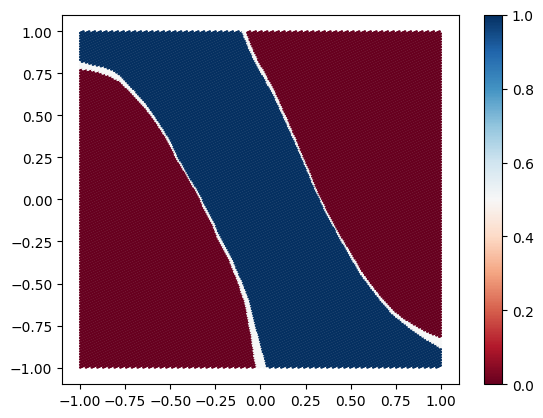

In [212]:
plt.scatter(predictions[:, 0], predictions[:, 1], c=predictions[:, 2], cmap='RdBu', s=0.5)
plt.colorbar()

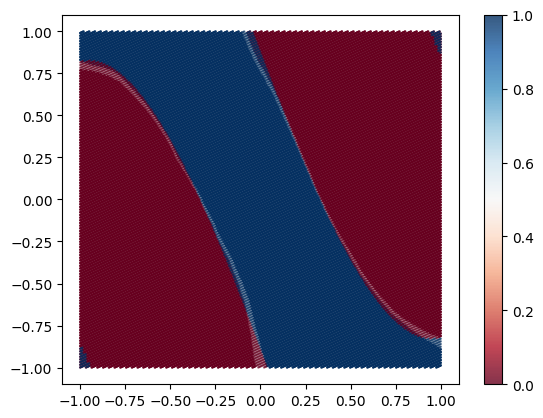

In [213]:
# plt.scatter(predictions1[:, 0], predictions1[:, 1], c=predictions1[:, 2], cmap='RdBu', s=0.5) 
plt.scatter(predictions[:, 0], predictions[:, 1], c=predictions[:, 2], cmap='RdBu', alpha=0.8, s=0.4)
plt.colorbar()
plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='RdBu', alpha=0.4, s=0.5)

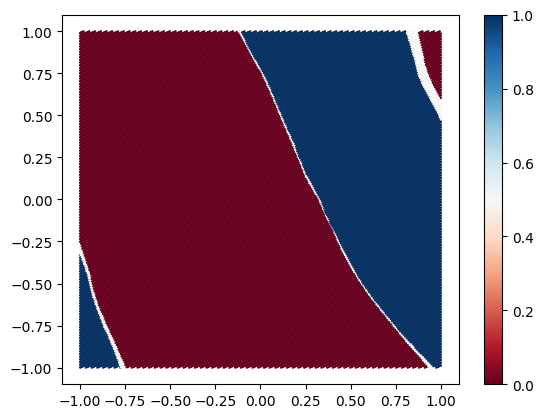

In [189]:
att1 =  attractor_classifications['arr_0'].item()['left'].copy()
# att1[:, 0] /= np.pi
# att1[:, 1] /= (2*np.pi)
predictions1 = att1.copy()
lower_bound = 0.4
upper_bound = 1 - lower_bound

predictions1[att1[:, 2] < lower_bound, 2] = 0
predictions1[att1[:, 2] >= upper_bound, 2] = 1
predictions1[(att1[:, 2] >= lower_bound) & (att1[:, 2] < upper_bound), 2] = 0.5
plt.scatter(predictions1[:, 0], predictions1[:, 1], c=predictions1[:, 2], cmap='RdBu', s=0.5)
plt.colorbar()
plt.show()

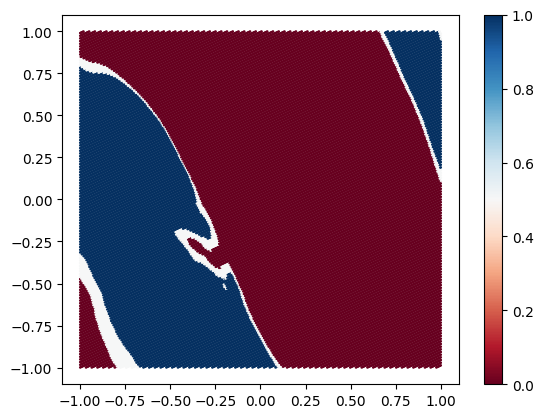

In [187]:
att2 =  attractor_classifications['arr_0'].item()['right'].copy()
# att1[:, 0] /= np.pi
# att1[:, 1] /= (2*np.pi)
predictions2 = att2.copy()
lower_bound = 0.4
upper_bound = 1 - lower_bound

predictions2[att2[:, 2] < lower_bound, 2] = 0
predictions2[att2[:, 2] >= upper_bound, 2] = 1
predictions2[(att2[:, 2] >= lower_bound) & (att2[:, 2] < upper_bound), 2] = 0.5
plt.scatter(predictions2[:, 0], predictions2[:, 1], c=predictions2[:, 2], cmap='RdBu', s=0.5)
plt.colorbar()
plt.show()

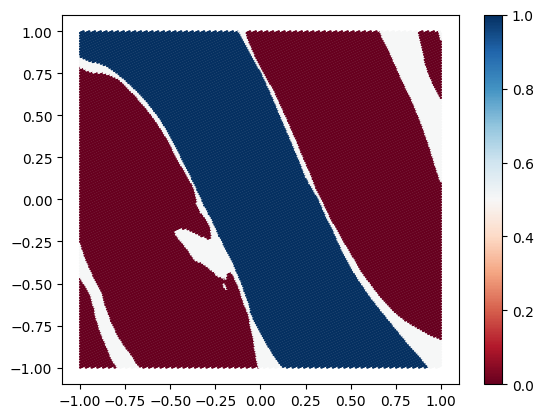

In [205]:
final_predictions = predictions.copy()
for i in range(data.shape[0]):
    if (predictions[i, 2] + predictions1[i, 2] + predictions2[i, 2]) > 1:
        final_predictions[i, 2] = 0.5
    elif predictions[i, 2] == 1:
        final_predictions[i, 2] = 1
    elif predictions1[i, 2] == 1 or predictions2[i, 2] == 1:
        final_predictions[i, 2] = 0
    else:
        final_predictions[i, 2] = 0.5
plt.scatter(final_predictions[:, 0], final_predictions[:, 1], c=final_predictions[:, 2], cmap='RdBu', s=0.5)
plt.colorbar()
plt.show()

In [43]:
import os
from glob import glob
import numpy as np
from tqdm import tqdm

data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/arcmg/data/cartpole_1k/cartpole_lqr1k"
data_files = glob(os.path.join(data_folder, '*.txt'))
lens = []
full_data = []
for file in tqdm(data_files):
    # print(file)
    data = np.loadtxt(file, delimiter=',')
    print(data.shape)
    
    # lens.append(data.shape[0])
#     full_data.append(data)
# full_data = np.concatenate(full_data, axis=0)

# # normalize between -1, 1
# full_data = full_data - np.mean(full_data, axis=0) 
# full_data = full_data / np.max(np.abs(full_data), axis=0)

  1%|          | 16/1440 [00:00<00:10, 142.12it/s]

(1001, 4)
(1001, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(1001, 4)
(999, 4)
(999, 4)
(1001, 4)
(999, 4)
(1001, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(1001, 4)
(1001, 4)


  3%|▎         | 44/1440 [00:00<00:12, 109.34it/s]

(1001, 4)
(999, 4)
(999, 4)
(999, 4)
(1001, 4)
(999, 4)
(1001, 4)
(999, 4)
(1001, 4)
(1001, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)


  5%|▍         | 68/1440 [00:00<00:12, 106.04it/s]

...

(1001, 4)
(999, 4)
(999, 4)
(999, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)


 99%|█████████▉| 1426/1440 [00:16<00:00, 85.54it/s]

(1001, 4)
(999, 4)
(1001, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(999, 4)
(999, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(1001, 4)
(999, 4)
(999, 4)


100%|██████████| 1440/1440 [00:16<00:00, 86.48it/s]

(1001, 4)
(999, 4)
(999, 4)
(999, 4)
(999, 4)
(999, 4)
(1001, 4)
(999, 4)
(1001, 4)


In [41]:
# full_data = full_data - np.mean(full_data, axis=0)
# full_data = full_data / np.std(full_data, axis=0)
np.max(full_data, axis=0), np.min(full_data, axis=0)


(array([1.        , 1.        , 1.        , 0.98032467]),
 array([-0.99287678, -0.99800321, -0.98782092, -1.        ]))